### Настройки

Начинаем с импорта библиотек

In [1]:
import pandas as pd
import psycopg2

Создаем соединение с заданными параметрами

In [2]:
DBNAME = 'project_sql'
USER = 'skillfactory'
PASSWORD = 'cCkxxLVrDE8EbvjueeMedPKt'
HOST = '84.201.134.129'
PORT = 5432

Запрос

In [3]:
connection = psycopg2.connect(
   dbname=DBNAME,
   user=USER,
   host=HOST,
   password=PASSWORD,
   port=PORT
)

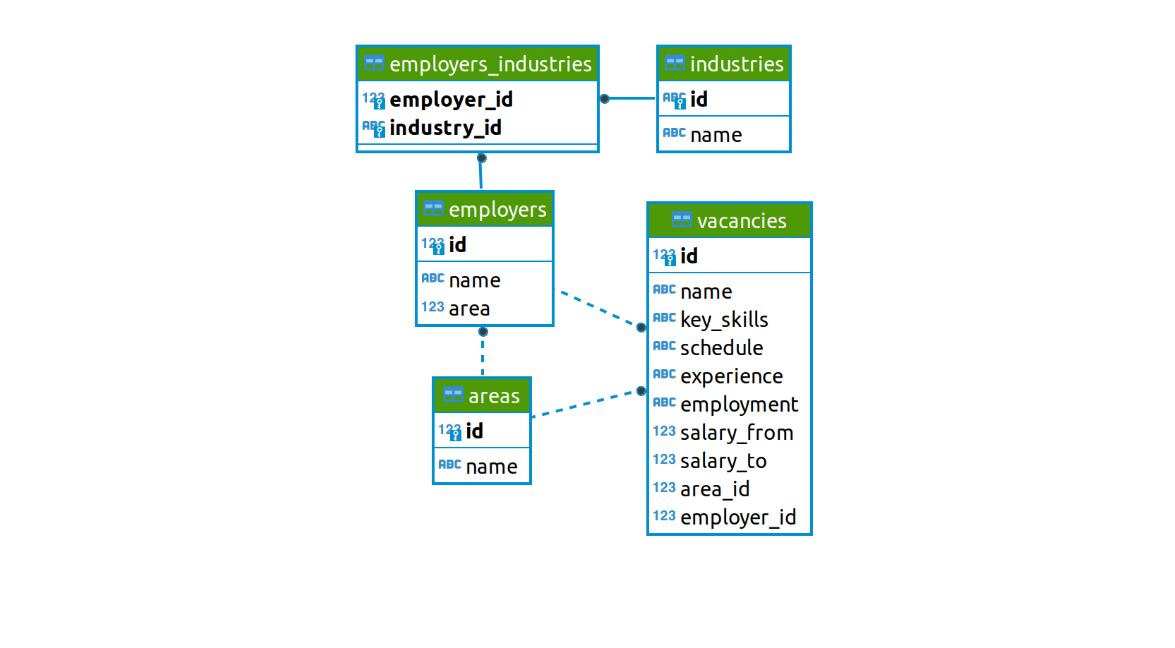

### **vacancies**

Таблица хранит в себе данные по вакансиям и содержит следующие столбцы:


Зарплатная вилка — это верхняя и нижняя граница оплаты труда в рублях (зарплаты в других валютах уже переведены в рубли). Соискателям она показывает, в каком диапазоне компания готова платить сотруднику на этой должности.


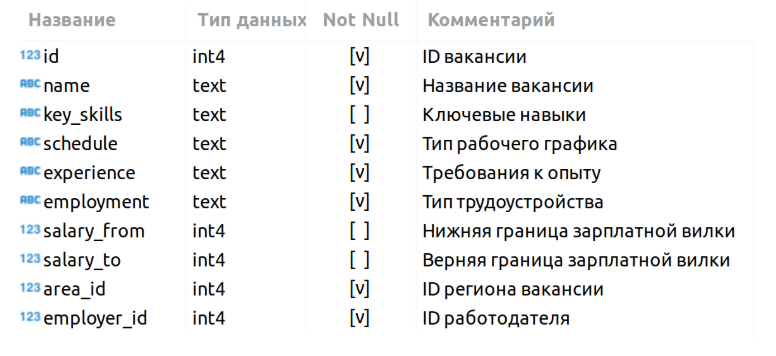

### **areas**

Таблица-справочник, которая хранит код региона и его название.



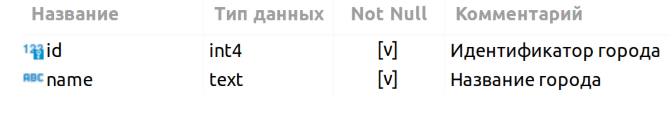

### **employers**

Таблица-справочник со списком работодателей.

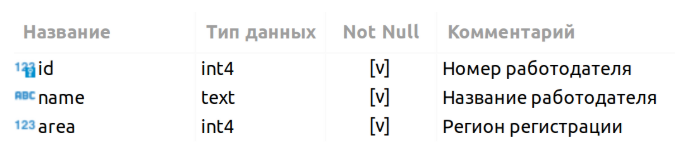

### **industries**

Таблица-справочник вариантов сфер деятельности работодателей.



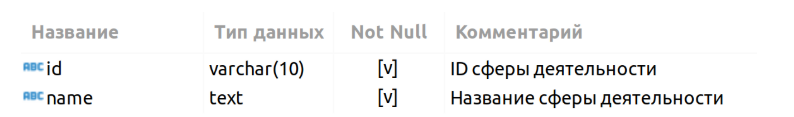

### **employers_industries**

Дополнительная таблица, которая существует для организации связи между работодателями и сферами их деятельности.

Эта таблица нужна нам, поскольку у одного работодателя может быть несколько сфер деятельности (или работодатели могут вовсе не указать их). Для удобства анализа необходимо хранить запись по каждой сфере каждого работодателя в отдельной строке таблицы.

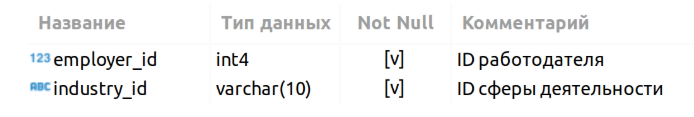

#### Задание 3.1
  *Сколько вакансий есть в базе?*

In [4]:
query = f'''select count(*)
            from vacancies

         '''

df = pd.read_sql_query(query, connection)
df


/tmp/ipykernel_175/3584908228.py:6: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query, connection)


,count
0,49197


#### Задание 3.2
  *Сколько работадателей есть?*

In [5]:
query = f'''select count(*)
            from employers

         '''

df = pd.read_sql_query(query, connection)
df


/tmp/ipykernel_175/3368785467.py:6: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query, connection)


,count
0,23501


#### Задание 3.3
  *Сколько регионов?*

In [6]:
query = f'''select count(distinct id)
            from areas

         '''

df = pd.read_sql_query(query, connection)
df

/tmp/ipykernel_175/1592535021.py:6: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query, connection)


,count
0,1362


#### Задание 3.4
  *Сколько сфер деятельности?*

In [7]:
query = f'''select count(distinct industry_id)
            from employers_industries

         '''

df = pd.read_sql_query(query, connection)
df

/tmp/ipykernel_175/2357194781.py:6: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query, connection)


,count
0,294


### -------------------------------------------------------------------

#### Задание 4.1
  *Напишите запрос, который позволит узнать, сколько (cnt) вакансий в каждом регионе (area).*

Выберите пятёрку лидеров по количеству вакансий:

Верхняя Пышма, Волхов, Сыктывкар, Жигулевск, Великие Луки;

Москва, Санкт-Петербург, Минск, Новосибирск, Алматы

Кизляр, Джизак, Эртиль, Арсеньев, Тура

Москва, Санкт-Петербург, Минск, Новосибирск, Алматы, Екатеринбург*

In [8]:
query = f'''select  count(v.id), a.name
            from vacancies v

            left join areas a on a.id = v.area_id
            group by a.name
            order by count(v.id) DESC

         '''

df = pd.read_sql_query(query, connection)
df

/tmp/ipykernel_175/4057311470.py:10: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query, connection)


,count,name
0,5333,Москва
1,2851,Санкт-Петербург
2,2112,Минск
3,2006,Новосибирск
4,1892,Алматы
...,...,...
764,1,Тарко-Сале
765,1,Новоаннинский
766,1,Бирск
767,1,Сасово


#### Задание 4.2
  *Посмотрим на зарплаты. У какого количества вакансий заполнено хотя бы одно из двух полей с зарплатой?*

In [9]:
query = f'''select  count(v.id)
            from vacancies v
            where salary_from is not null or salary_to is not null


         '''

df = pd.read_sql_query(query, connection)
df

/tmp/ipykernel_175/2554548180.py:8: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query, connection)


,count
0,24073


#### Задание 4.3

  *Найдите средние значения для нижней и верхней границы зарплатной вилки. Округлите значения до целого числа.*

In [10]:
query = f'''select  avg(salary_from) , avg (salary_to)
            from vacancies v
            --- where salary_from is not null or salary_to is not null


         '''

df = pd.read_sql_query(query, connection)
df

/tmp/ipykernel_175/3954793845.py:8: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query, connection)


,avg,avg
0,71064.657901,110536.741923


#### Задание 4.4

  *Напишите запрос, который выведет количество вакансий для каждого сочетания типа рабочего графика (schedule) и типа трудоустройства (employment), используемого в вакансиях. Какая пара находится на втором месте по популярности?*

Полный день — Полная занятость

Вахтовый метод — Проектная работа

Удалённая работа — Полная занятость

Гибкий график — Полная занятость

Удалённая работа — Частичная занятость*

In [11]:
query = f'''
    SELECT
        schedule,
        employment,
        COUNT(id) as cnt
    FROM
        vacancies
    GROUP BY
        schedule,
        employment
    ORDER BY
        cnt DESC;
'''
df = pd.read_sql_query(query, connection)
df

/tmp/ipykernel_175/277549855.py:14: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query, connection)


,schedule,employment,cnt
0,Полный день,Полная занятость,35367
1,Удаленная работа,Полная занятость,7802
2,Гибкий график,Полная занятость,1593
3,Удаленная работа,Частичная занятость,1312
4,Сменный график,Полная занятость,940
5,Полный день,Стажировка,569
6,Вахтовый метод,Полная занятость,367
7,Полный день,Частичная занятость,347
8,Гибкий график,Частичная занятость,312
9,Полный день,Проектная работа,141


#### Задание 4.4

  *Напишите запрос, выводящий значения поля Требуемый опыт работы (experience) в порядке возрастания количества вакансий, в которых указан данный вариант опыта.*
  
Выберите верный вариант ответа.

Более 6 лет — Нет опыта — От 3 до 6 лет — От 1 года до 3 лет

От 1 года до 3 лет — От 3 до 6 лет — Нет опыта — Более 6 лет

Более 6 лет — От 3 до 6 лет — Нет опыта — От 1 года до 3 лет

In [12]:
query = f'''
    SELECT
        experience,
        COUNT(id) as cnt
    FROM
        vacancies
    GROUP BY
        experience
    ORDER BY
        cnt
'''
df = pd.read_sql_query(query, connection)
df

/tmp/ipykernel_175/1142287994.py:12: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query, connection)


,experience,cnt
0,Более 6 лет,1337
1,Нет опыта,7197
2,От 3 до 6 лет,14511
3,От 1 года до 3 лет,26152


### Задание 5.1

Напишите запрос, который позволит узнать, какие работодатели находятся на первом и пятом месте по количеству вакансий.
Выберите верный вариант ответа:

Яндекс — ИК СИБИНТЕК

Cybernet (Кибернет) — СНПА Промышленная безопасность

Яндекс — Газпром нефть

Cybernet (Кибернет) — Газпром нефть

In [13]:
query = f'''
    SELECT
 e.name, count (e.id)
    FROM vacancies  v
  left join employers  e  on e.id = v.employer_id
group by e.name
order by count (e.id) desc

'''
df = pd.read_sql_query(query, connection)
df.head(6)

/tmp/ipykernel_175/2798592550.py:10: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query, connection)


,name,count
0,Яндекс,1933
1,Ростелеком,491
2,Тинькофф,444
3,СБЕР,428
4,Газпром нефть,331
5,ИК СИБИНТЕК,327


### Задание 5.2

Напишите запрос, который для каждого региона выведет количество работодателей и вакансий в нём.

Среди регионов, в которых нет вакансий, найдите тот, в котором наибольшее количество работодателей. Впишите его название в поле ниже в том виде, который вернул запрос.

In [14]:

query = f'''
    with temp1 as
(
  SELECT
 a.name ,a.id ,  count(v.id)
  FROM areas  a
  left join vacancies  v  on a.id = v.area_id
group by a.name, a.id
having  count(v.id) < 1
)



select
a.name, count(e.name)

from temp1 a
inner join employers e on e.area = a.id
group by a.name
order by count(e.name) desc

'''

df = pd.read_sql_query(query, connection)
df

/tmp/ipykernel_175/850086953.py:24: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query, connection)


,name,count
0,Россия,410
1,Казахстан,207
2,Московская область,75
3,Краснодарский край,19
4,Беларусь,18
...,...,...
181,Дубровно,1
182,Эквадор,1
183,Рыбное,1
184,Парфино,1


### Задание 5.3

Для каждого работодателя посчитайте количество регионов, в которых он публикует свои вакансии.

Выберите максимальное значение из получившегося списка.

In [15]:
query = f'''
    SELECT
 e.name , count(distinct a.name)
    FROM employers  e
left join vacancies  v  on e.id = v.employer_id

left join areas a  on a.id = v.area_id


group by e.name
order by count(distinct a.name) desc



'''
df = pd.read_sql_query(query, connection)
df.head(6)

/tmp/ipykernel_175/3980353690.py:16: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query, connection)


,name,count
0,Яндекс,181
1,Ростелеком,152
2,Спецремонт,116
3,Поляков Денис Иванович,88
4,ООО ЕФИН,71
5,Совкомбанк,63


### Задание 5.4

Напишите запрос для подсчёта количества работодателей, у которых не указана сфера деятельности.

Введите количество, которое вернул запрос, в поле ниже.

In [16]:
query = f'''
    SELECT
count (distinct e.id)
    FROM employers  e
left join employers_industries  ei  on ei.employer_id = e.id
left join industries i on i.id = ei.industry_id

where ei.employer_id is NULL




'''
df = pd.read_sql_query(query, connection)
df.head(6)

/tmp/ipykernel_175/506816862.py:14: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query, connection)


,count
0,8419


### Задание 5.5

Напишите запрос, чтобы узнать название компании, находящейся на третьем месте в алфавитном списке (по названию) компаний, у которых указано четыре сферы деятельности.

Введите в поле ниже название этой компании так же, как оно указано в результате запроса.

In [17]:
query = f'''
    SELECT
 e.id, e.name, count(i.id)
    FROM employers  e
left join employers_industries  ei  on ei.employer_id = e.id
left join industries i on i.id = ei.industry_id
group by e.id, e.name
having count(i.id)= 4
order by e.name


'''
df = pd.read_sql_query(query, connection)
df.head(6)

/tmp/ipykernel_175/3040324699.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query, connection)


,id,name,count
0,800646,101 Интернет,4
1,763400,21vek.by,4
2,64174,2ГИС,4
3,29890,2К,4
4,1980996,4 пикселя +,4
5,600071,5lb,4


### Задание 5.6

С помощью запроса выясните, у какого количества работодателей в качестве сферы деятельности указана «Разработка программного обеспечения».

In [18]:
query = f'''
    SELECT
count (distinct employer_id)
    FROM employers  e
left join employers_industries  ei  on ei.employer_id = e.id
left join industries i on i.id = ei.industry_id


where i.name = 'Разработка программного обеспечения'


'''
df = pd.read_sql_query(query, connection)
df.head(6)

/tmp/ipykernel_175/1049768500.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query, connection)


,count
0,3553


### Задание 5.7


Для компании «Яндекс» выведите список регионов-миллионников, в которых представлены вакансии компании, вместе с количеством вакансий в этих регионах. Также добавьте строку Total с общим количеством вакансий компании, собранных в этой таблице. Должна получиться выборка такого вида (приведён пример результата для компании SberTech):

In [19]:


query = f'''
    SELECT
a.name , count (v.id)
    FROM vacancies  v
    left join areas a on a.id = v.area_id
    left join employers e on e.id = v.employer_id

where  e.name = 'Яндекс'  and a.name in (
'Москва',
'Санкт-Петербург',
'Новосибирск',
'Екатеринбург',
'Казань',
'Красноярск',
'Нижний Новгород',
'Челябинск'	,
'Уфа',
'Краснодар',
'Самара',
'Ростов-на-Дону',
'Омск',
'Воронеж',
'Пермь',
'Волгоград')

group by a.name


/*
union all

 sum( count (v.id)) as 'kol-vo'
    FROM vacancies  v
    left join areas a on a.id = v.area_id
    left join employers e on e.id = v.employer_id

where  e.name = 'Яндекс'  and a.name in (
'Москва',
'Санкт-Петербург',
'Новосибирск',
'Екатеринбург',
'Казань',
'Красноярск',
'Нижний Новгород',
'Челябинск'	,
'Уфа',
'Краснодар',
'Самара',
'Ростов-на-Дону',
'Омск',
'Воронеж',
'Пермь',
'Волгоград')
*/


'''
df = pd.read_sql_query(query, connection)
df
a = df['count'].sum()
print (a)

/tmp/ipykernel_175/1903247652.py:58: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query, connection)


485


**--------------------------------------------------------------------------------------**

### Задание 6.1


Сколько вакансий имеет отношение к данным:

In [20]:
query = f'''
    SELECT
*
    FROM vacancies  e
where lower(name) like '%data%' or lower(name) like '%данн%'


'''
df = pd.read_sql_query(query, connection)
df.shape[0]

/tmp/ipykernel_175/2012997904.py:9: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query, connection)


1771

### Задание 6.2


Сколько есть подходящих вакансий для начинающего дата-сайентиста?

Будем считать вакансиями для дата-сайентистов такие, в названии которых есть хотя бы одно из следующих сочетаний:

‘data scientist’;

‘data science’;

‘исследователь данных’;

‘ML’ (здесь не нужно брать вакансии по HTML);

‘machine learning’;

‘машинн%обучен%’.

В следующих заданиях мы продолжим работать с вакансиями по указанному выше условию (уже не учитывая вакансии уровня Junior).

Считаем вакансиями для специалистов уровня Junior следующие:

в названии есть слово “junior”
или требуемый опыт — «Нет опыта»
или тип трудоустройства — «Стажировка».

В качестве ответа запишите количество вакансий, которое вернул запрос

In [21]:
query = f'''
    SELECT
count(*)
    FROM vacancies  e
where (lower(name) like '%data scientist%'
or lower(name) like '%data science%'
or lower(name) like '%исследователь данных%'
or lower (name) like '%машинн%обучен%'
or lower(name) like '%machine learning%'
or name like '%ML%' and  name not like '%HTML%')


and (lower(name) like '%junior%'
or experience like 'Нет опыта'
or schedule like 'Стажировка')


'''
df = pd.read_sql_query(query, connection)
df

/tmp/ipykernel_175/1042102594.py:19: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query, connection)


,count
0,51


### Задание 6.3


Сколько есть вакансий для DS, в которых в качестве ключевого навыка указан SQL или postgres?

В качестве ответа запишите количество, которое вернул запрос.

In [27]:
query = f'''
    SELECT
count(*)
    FROM vacancies  e
where (lower(name) like '%data scientist%'
or lower(name) like '%data science%'
or lower(name) like '%исследователь данных%'
or lower (name) like '%машинн%обучен%'
or lower(name) like '%machine learning%'
or  (lower (name) like '%ml%' and  lower(name) not like '%html%')
)



and
(
lower(key_skills) like '%sql%'
or lower(key_skills) like '%postgres%'
)


'''
df = pd.read_sql_query(query, connection)
df

/tmp/ipykernel_175/3283345120.py:23: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query, connection)


,count
0,229


### Задание 6.4


С помощью запроса, аналогичного предыдущему, проверьте, насколько популярен Python в требованиях работодателей к DS. Вычислите количество вакансий, в которых в качестве ключевого навыка указан Python.

В качестве ответа запишите количество, которое вернул запрос.

In [32]:
query = f'''

    SELECT
count(*)
    FROM vacancies  e
where (
   lower(name) like '%data scientist%'
or lower(name) like '%data science%'
or lower(name) like '%исследователь данных%'
or lower (name) like '%машинн%обучен%'
or lower(name) like '%machine learning%'
or (lower (name) like '%ml%' and  lower(name) not like '%html%')
)




and

lower(key_skills) like '%python%'




'''
df = pd.read_sql_query(query, connection)
df

/tmp/ipykernel_175/572765567.py:26: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query, connection)


,count
0,357


### Задание 6.5


Сколько ключевых навыков в среднем указывают в вакансиях для DS?

Ответ округлите до двух знаков после точки-разделителя.

In [38]:
query = f'''

SELECT
/*    id,
    name,
    key_skills, */
     avg (LENGTH(key_skills) - LENGTH(REPLACE(key_skills, '\t', '')))  + 1 AS skill_count
    from vacancies v
WHERE
    (
        LOWER(v.name) LIKE '%data scientist%'
        OR LOWER(v.name) LIKE '%data science%'
        OR LOWER(v.name) LIKE '%исследователь данных%'
        OR (v.name LIKE '%ML%' AND v.name NOT LIKE '%HTML%')
        OR LOWER(v.name) LIKE '%machine learning%'
        OR LOWER(v.name) LIKE '%машинн%обучен%'
    )
    AND v.key_skills IS NOT NULL
    AND (v.key_skills) != ''


    '''

df = pd.read_sql_query(query, connection)
df

/tmp/ipykernel_175/2311067715.py:24: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query, connection)


,skill_count
0,6.406032


### Задание 6.6

Напишите запрос, позволяющий вычислить, какую зарплату для DS в среднем указывают для каждого типа требуемого опыта (уникальное значение из поля experience).

При решении задачи примите во внимание следующее:

Рассматриваем только вакансии, у которых заполнено хотя бы одно из двух полей с зарплатой.
Если заполнены оба поля с зарплатой, считаем зарплату по каждой вакансии как сумму двух полей, делённую на 2. Если заполнено только одно из полей, его и считаем зарплатой по вакансии.

Если в расчётах участвует null, в результате он тоже даст null (посмотрите, что возвращает запрос select 1 + null).

Чтобы избежать этой ситуации, мы воспользуемся функцией coalesce, которая заменит null на значение, которое мы передадим. Например, посмотрите, что возвращает запрос select 1 + coalesce(null, 0).

Выясните, на какую зарплату в среднем может рассчитывать дата-сайентист с опытом работы от 3 до 6 лет. Результат округлите до целого числа.

In [45]:
query = f'''


with temp1 as (
    SELECT
        experience,
        CASE
            WHEN salary_from IS NOT NULL AND salary_to IS NOT NULL THEN (salary_from + salary_to) / 2
            WHEN salary_from IS NOT NULL THEN salary_from
            WHEN salary_to IS NOT NULL THEN salary_to
            ELSE NULL
        END AS salary
    FROM vacancies v
    WHERE
         (
        LOWER(v.name) LIKE '%data scientist%'
        OR LOWER(v.name) LIKE '%data science%'
        OR LOWER(v.name) LIKE '%исследователь данных%'
        OR (v.name LIKE '%ML%' AND v.name NOT LIKE '%HTML%')
        OR LOWER(v.name) LIKE '%machine learning%'
        OR LOWER(v.name) LIKE '%машинн%обучен%'
    )
        AND (salary_from IS NOT NULL OR salary_to IS NOT NULL)
)


select experience , avg(salary)
from temp1
group by experience



    '''

df = pd.read_sql_query(query, connection)
df

/tmp/ipykernel_175/3515363554.py:35: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query, connection)


,experience,avg
0,От 3 до 6 лет,243114.666667
1,От 1 года до 3 лет,139674.750000
2,Нет опыта,74642.857143


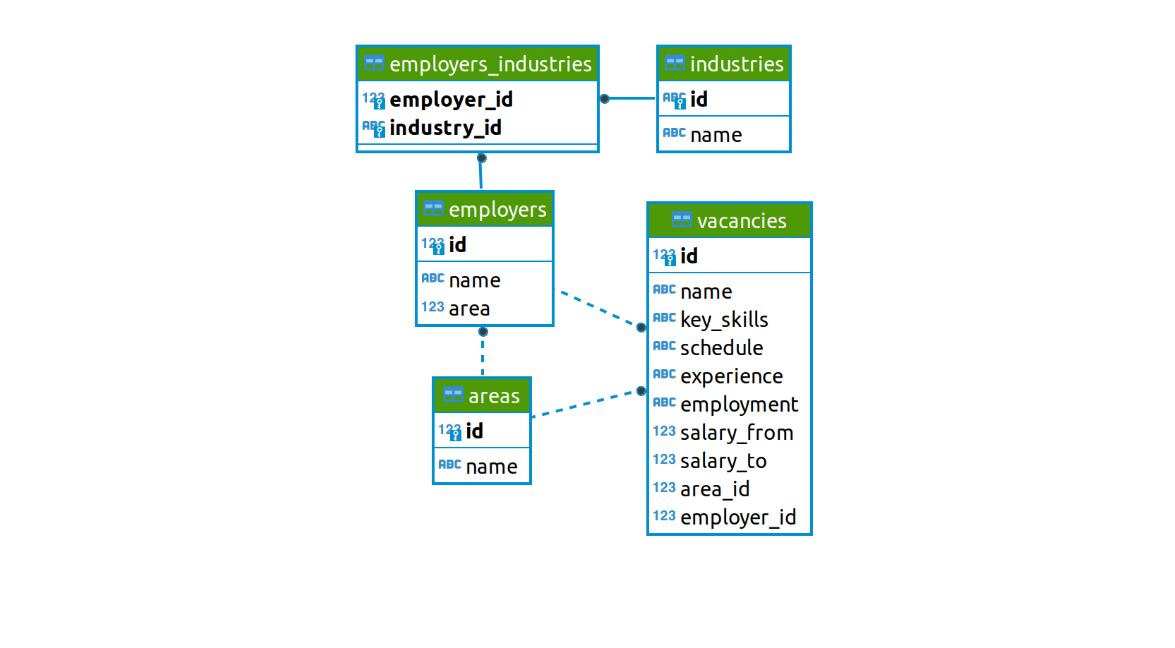